**Assignment 4: Regularization**

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

**Question 1**

1. Adding a penalty to MSE allows the model to both reduce prediction error, and also trying to avoid having very large coefficients. The penalty makes large coefficients “cost” more, so the model only keeps them if they are actually useful for prediction. The intuition is that large coefficients can make the model too sensitive to small changes in the data, which increases variance and can cause overfitting. By shrinking the coefficients toward 0, regularization makes the model simpler and more stable. This may slightly increase bias, but it helps reduce variance and makes the model more reliable on new data.

2. Regularization changes how strongly the model is penalized for large coefficients. If the penalty is small, the model is closer to regular linear regression. It can fit the training data more closely, so it has lower bias but higher variance. if the penalty is large, the coefficients shrink closer to 0. The model becomes simpler. This increases bias a little, but lowers variance because the predictions become less sensitive to changes in the data.

3. LASSO uses the absolute values of the coefficients as the penalty, while Ridge uses the squared values of the coefficients. Because of this, LASSO can shrink some coefficients exactly to 0, allowing it to remove certain variables completely. Ridge shrinks coefficients toward 0, but usually does not make them exactly 0. As a result, LASSO typically gives a model with only a smaller set of selected predictors, while Ridge usually keeps all predictors in the model but reduces their influence.

4. For regularized regression, we z-score the quantitative variables so they are on a comparable scale, because the penalty acts on coefficient size. We typically z-score the quantitative predictors before regularized regression by subtracting the mean and dividing by the standard deviation.

5. We use cross-validation to find the value that gives the best predictive performance.

6. No. The penalty is used only to fit the model on training data. Cross-validation measures predictive performance on new data, so we use the ordinary MSE on the validation set.

**Question 2**

1. 

In [58]:
df = pd.read_csv('cars_hw.csv')
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [59]:
df["Age"] = 2026 - df["Make_Year"]
X = df[["Mileage_Run", "Age"]]


In [60]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [61]:
#polynomial features
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

X_poly = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(["Mileage_Run", "Age"]))

#normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)


X_scaled = pd.DataFrame(X_scaled, columns=X_poly.columns)
X_scaled.head()

,Mileage_Run,Age,Mileage_Run^2,Mileage_Run Age,Age^2,Mileage_Run^3,Mileage_Run^2 Age,Mileage_Run Age^2,Age^3
0,0.124692,-0.013092,-0.137673,-0.045119,-0.157264,-0.294615,-0.230767,-0.195586,-0.270422
1,-0.872334,0.341858,-0.791316,-0.677034,0.190081,-0.661216,-0.718186,-0.564890,0.044089
2,-0.493517,-0.722993,-0.600623,-0.665157,-0.742267,-0.581863,-0.648004,-0.700911,-0.718398
3,-0.241655,-0.013092,-0.434732,-0.301067,-0.157264,-0.492295,-0.458906,-0.364354,-0.270422
4,-0.674578,-0.013092,-0.700583,-0.603528,-0.157264,-0.627064,-0.663078,-0.563792,-0.270422


2. 

In [62]:
from sklearn.linear_model import LinearRegression

In [63]:
y = df["Price"]

#linear regression
lr = LinearRegression()
lr.fit(X_scaled, y)

coef = pd.Series(lr.coef_, index=X_scaled.columns)


print(coef)

Mileage_Run          9.117748e+05
Age                 -2.481722e+05
Mileage_Run^2       -2.072926e+05
Mileage_Run Age     -1.671212e+06
Age^2                3.505507e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    3.388195e+05
Mileage_Run Age^2    7.167816e+05
Age^3               -2.100379e+05
dtype: float64


In [64]:
print("Interaction coefficient:", coef["Mileage_Run Age"])

Interaction coefficient: -1671212.356391895


3. 

In [65]:
from sklearn.linear_model import LassoCV

In [66]:
alphas = np.logspace(1,3,20)

reg = LassoCV(alphas=alphas, cv=20)
reg.fit(X_scaled, y)

print(reg.alpha_)

69.51927961775606


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.385e+10, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.463e+11, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

4. 

In [74]:
cv_mse = reg.mse_path_.mean(axis=1)

mse_df = pd.DataFrame({
    "alpha": reg.alphas_,
    "cv_mse": cv_mse
})

print(f"Optimal cost hyperparameter: {reg.alpha_}")

Optimal cost hyperparameter: 69.51927961775606


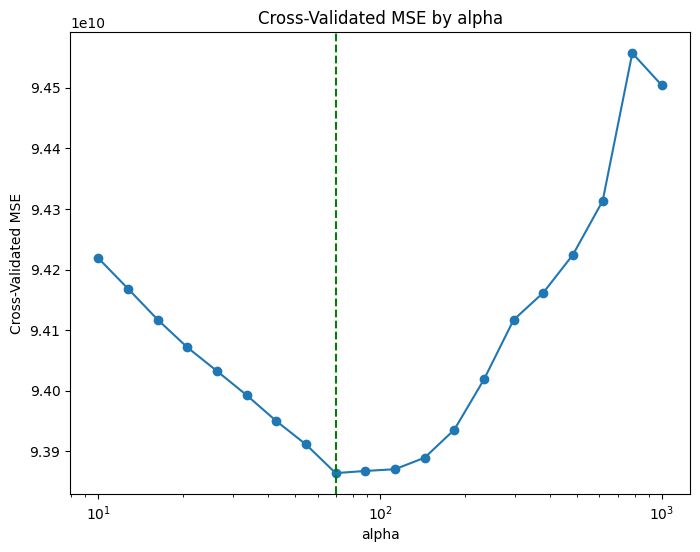

In [75]:
# plot
plt.figure(figsize=(8,6))
plt.plot(mse_df["alpha"], mse_df["cv_mse"], marker="o")
plt.axvline(x=reg.alpha_, color="green", linestyle="--", linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("Cross-Validated MSE by alpha")
plt.show()

5. 

In [53]:
from sklearn.linear_model import lasso_path

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.435e+12, tolerance: 6.675e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.874e+12, tolerance: 6.675e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

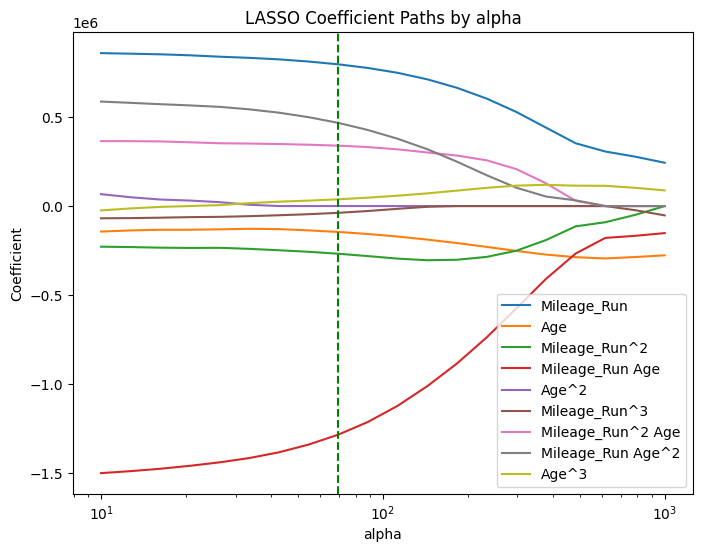

In [80]:
#lasso coefficient paths
alphas_lasso, coefs_lasso, _ = lasso_path(X_scaled, y, alphas=alphas)

#plot
plt.figure(figsize=(8,6))

for i in range(coefs_lasso.shape[0]):
    plt.plot(alphas_lasso, coefs_lasso[i], label=X_scaled.columns[i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient")
plt.axvline(x=reg.alpha_, color="green", linestyle="--", linewidth=1.5)
plt.title("LASSO Coefficient Paths by alpha")
plt.legend()
plt.show()

6.

In [83]:
coef = pd.Series(reg.coef_, index=X_scaled.columns)

print("Selected features:")
print(coef[coef != 0])

print("\nProportion set equal to zero:")
print((coef == 0).mean())

Selected features:
Mileage_Run          611783.868767
Age                 -397507.787042
Mileage_Run^2       -519555.261867
Mileage_Run Age     -473871.400459
Age^2                230721.078724
Mileage_Run^3         97835.641353
Mileage_Run^2 Age    318218.774588
Mileage_Run Age^2    -35056.210190
Age^3                 42493.187416
dtype: float64

Proportion set equal to zero:
0.0


All 9 features were selected, since none of the LASSO coefficients were exactly equal to 0 at the chosen cross-validated alpha. Therefore, the proportion set equal to zero is 0.0.

7.The LASSO coefficients were all reduced in magnitude compared with the ordinary linear regression coefficients, so none increased in absolute value. However, a few changed sign: Mileage_Run^3, Mileage_Run Age^2, and Age^3. (Comparing results from question2.2)

**Question 3**

1. 

In [84]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [85]:
X_num = df[["age", "ejection_fraction", "serum_creatinine"]]

poly_num = PolynomialFeatures(degree=3, include_bias=False)
X_num_poly = poly_num.fit_transform(X_num)

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num_poly)

In [86]:
X_num_scaled = pd.DataFrame(
    X_num_scaled,
    columns=poly_num.get_feature_names_out(["age", "ejection_fraction", "serum_creatinine"])
)
X_num_scaled.head()

,age,ejection_fraction,serum_creatinine,age^2,age ejection_fraction,age serum_creatinine,ejection_fraction^2,ejection_fraction serum_creatinine,serum_creatinine^2,age^3,age^2 ejection_fraction,age^2 serum_creatinine,age ejection_fraction^2,age ejection_fraction serum_creatinine,age serum_creatinine^2,ejection_fraction^3,ejection_fraction^2 serum_creatinine,ejection_fraction serum_creatinine^2,serum_creatinine^3
0,1.192945,-1.530560,0.490057,1.177180,-0.939354,0.777328,-1.197120,-0.287340,0.073541,1.124026,-0.450915,0.942348,-1.049525,-0.134955,0.142821,-0.925154,-0.453114,-0.114940,-0.075575
1,-0.491279,-0.007077,-0.284552,-0.539187,-0.267742,-0.365953,-0.146835,-0.214284,-0.220393,-0.562311,-0.419260,-0.420054,-0.278632,-0.300976,-0.227841,-0.248601,-0.197693,-0.176609,-0.156017
2,0.350833,-1.530560,-0.090900,0.252982,-1.167019,-0.031334,-1.197120,-0.518041,-0.161606,0.152154,-0.812686,-0.019293,-1.111920,-0.484473,-0.149244,-0.925154,-0.527114,-0.205256,-0.143415
3,-0.912335,-1.530560,0.490057,-0.885761,-1.508517,0.115061,-1.197120,-0.287340,0.073541,-0.835393,-1.258439,-0.156737,-1.205513,-0.421199,-0.021000,-0.925154,-0.453114,-0.114940,-0.075575
4,0.350833,-1.530560,1.264666,0.252982,-1.167019,1.237428,-1.197120,0.020262,0.524239,0.152154,-0.812686,1.075626,-1.111920,0.063909,0.511486,-0.925154,-0.354449,0.058167,0.111038


In [89]:
X_cat = df[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]

poly_cat = PolynomialFeatures(degree=4, include_bias=False, interaction_only=True)
X_cat_int = poly_cat.fit_transform(X_cat)

X_cat_int = pd.DataFrame(
    X_cat_int,
    columns=poly_cat.get_feature_names_out(["anaemia", "diabetes", "high_blood_pressure", "smoking"])
)

In [88]:
X = pd.concat(
    [X_num_scaled.reset_index(drop=True), X_cat_int.reset_index(drop=True)],
    axis=1
)

y = df["DEATH_EVENT"]

X.head()

,age,ejection_fraction,serum_creatinine,age^2,age ejection_fraction,age serum_creatinine,ejection_fraction^2,ejection_fraction serum_creatinine,serum_creatinine^2,age^3,...,anaemia high_blood_pressure,anaemia smoking,diabetes high_blood_pressure,diabetes smoking,high_blood_pressure smoking,anaemia diabetes high_blood_pressure,anaemia diabetes smoking,anaemia high_blood_pressure smoking,diabetes high_blood_pressure smoking,anaemia diabetes high_blood_pressure smoking
0,1.192945,-1.530560,0.490057,1.177180,-0.939354,0.777328,-1.197120,-0.287340,0.073541,1.124026,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.491279,-0.007077,-0.284552,-0.539187,-0.267742,-0.365953,-0.146835,-0.214284,-0.220393,-0.562311,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.350833,-1.530560,-0.090900,0.252982,-1.167019,-0.031334,-1.197120,-0.518041,-0.161606,0.152154,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.912335,-1.530560,0.490057,-0.885761,-1.508517,0.115061,-1.197120,-0.287340,0.073541,-0.835393,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.350833,-1.530560,1.264666,0.252982,-1.167019,1.237428,-1.197120,0.020262,0.524239,0.152154,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


2.

In [94]:
lr = LinearRegression()
lr.fit(X, y)

lr_coef = pd.Series(lr.coef_, index=X.columns)
print(lr_coef)

age                                             1.619432
ejection_fraction                              -2.062277
serum_creatinine                               -0.757092
age^2                                          -3.717758
age ejection_fraction                          -0.800726
age serum_creatinine                            1.707056
ejection_fraction^2                             3.352956
ejection_fraction serum_creatinine              2.569764
serum_creatinine^2                             -2.640240
age^3                                           1.963124
age^2 ejection_fraction                         1.054408
age^2 serum_creatinine                         -0.679042
age ejection_fraction^2                        -0.066433
age ejection_fraction serum_creatinine         -1.626996
age serum_creatinine^2                          1.444075
ejection_fraction^3                            -1.245337
ejection_fraction^2 serum_creatinine           -1.151378
ejection_fraction serum_creatin

Yes, some of the signs appear counterintuitive if interpreted in isolation. For example, age has a positive coefficient, while age^2 is negative and age^3 is positive again. However, this does not necessarily indicate a contradiction, because once higher-order terms and interactions are included, the effect of a variable is no longer captured by its linear term alone. Instead, the overall relationship is determined by the combination of the linear, polynomial, and interaction terms.

3.

In [93]:
alphas = np.logspace(-5, 5, 30)

reg = LassoCV(alphas=alphas, cv=20, max_iter=100000)
reg.fit(X, y)

print(reg.alpha_)

0.005736152510448681


4.

Optimal cost hyperparameter: 0.005736152510448681


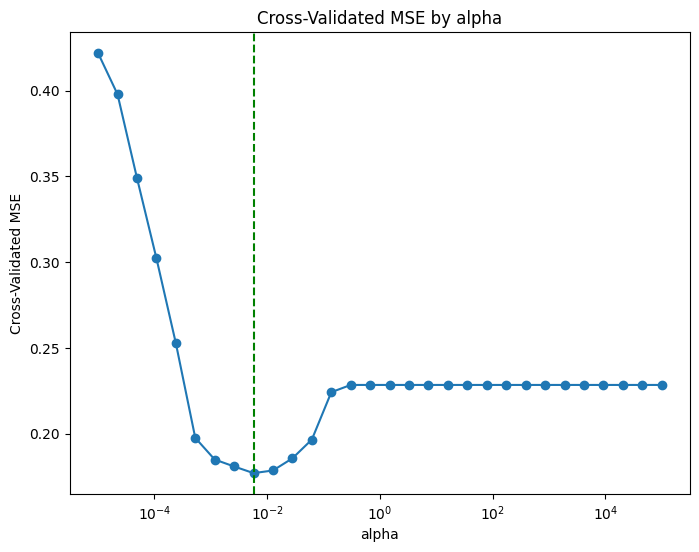

In [95]:
cv_mse = reg.mse_path_.mean(axis=1)

mse_df = pd.DataFrame({
    "alpha": reg.alphas_,
    "cv_mse": cv_mse
})

print(f"Optimal cost hyperparameter: {reg.alpha_}")

plt.figure(figsize=(8,6))
plt.plot(mse_df["alpha"], mse_df["cv_mse"], marker="o")
plt.axvline(x=reg.alpha_, color="green", linestyle="--", linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("Cross-Validated MSE by alpha")
plt.show()

5.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.181e-01, tolerance: 9.600e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.807e-02, tolerance: 9.600e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

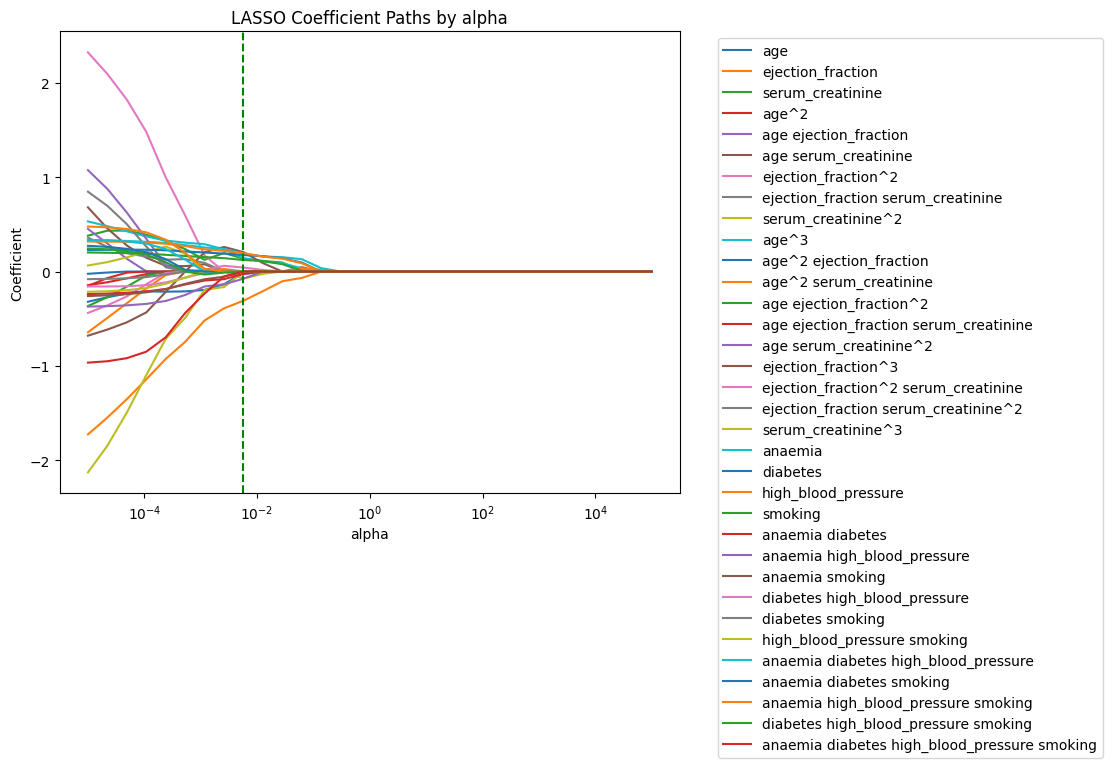

In [96]:
alphas_lasso, coefs_lasso, _ = lasso_path(X, y, alphas=alphas)

plt.figure(figsize=(8,6))

for i in range(coefs_lasso.shape[0]):
    plt.plot(alphas_lasso, coefs_lasso[i], label=X.columns[i])

plt.axvline(x=reg.alpha_, color="green", linestyle="--", linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient")
plt.title("LASSO Coefficient Paths by alpha")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

6

In [97]:
lasso_coef = pd.Series(reg.coef_, index=X.columns)

print("Selected features:")
print(lasso_coef[lasso_coef != 0])

print("\nProportion set equal to zero:")
print((lasso_coef == 0).mean())

Selected features:
ejection_fraction                      -0.329656
serum_creatinine                        0.116875
age^3                                   0.117992
ejection_fraction^3                     0.204822
ejection_fraction^2 serum_creatinine    0.032801
serum_creatinine^3                     -0.043266
anaemia                                 0.014178
diabetes                                0.000607
high_blood_pressure                     0.013608
diabetes high_blood_pressure            0.053968
diabetes smoking                        0.003466
high_blood_pressure smoking             0.017805
dtype: float64

Proportion set equal to zero:
0.6470588235294118


The features selected by LASSO are ejection_fraction, serum_creatinine, age^3, ejection_fraction^3, ejection_fraction^2 serum_creatinine, serum_creatinine^3, anaemia, diabetes, high_blood_pressure, diabetes high_blood_pressure, diabetes smoking, and high_blood_pressure smoking. The proportion of coefficients set equal to zero is about 0.647, so roughly 64.7% of the features were removed by the regularization.

Compared with the ordinary linear regression, the LASSO coefficients are much smaller in magnitude overall, so none of the selected coefficients appear to increase in magnitude after regularization. Some coefficients do change sign. For example, serum_creatinine changes from negative in the linear model to positive in LASSO, ejection_fraction^3 changes from negative to positive, ejection_fraction^2 serum_creatinine changes from negative to positive, anaemia, diabetes, and high_blood_pressure all change from negative to positive, and serum_creatinine^3 changes from positive to negative.

I think the LASSO sign patterns seem more reasonable because regularization makes the model less sensitive to noise. Since the unregularized linear model includes many polynomial and interaction terms, its coefficients can be unstable and harder to interpret. LASSO reduces this instability by shrinking coefficients and removing some variables, which lowers variance and usually leads to a more interpretable model.

**Question4**

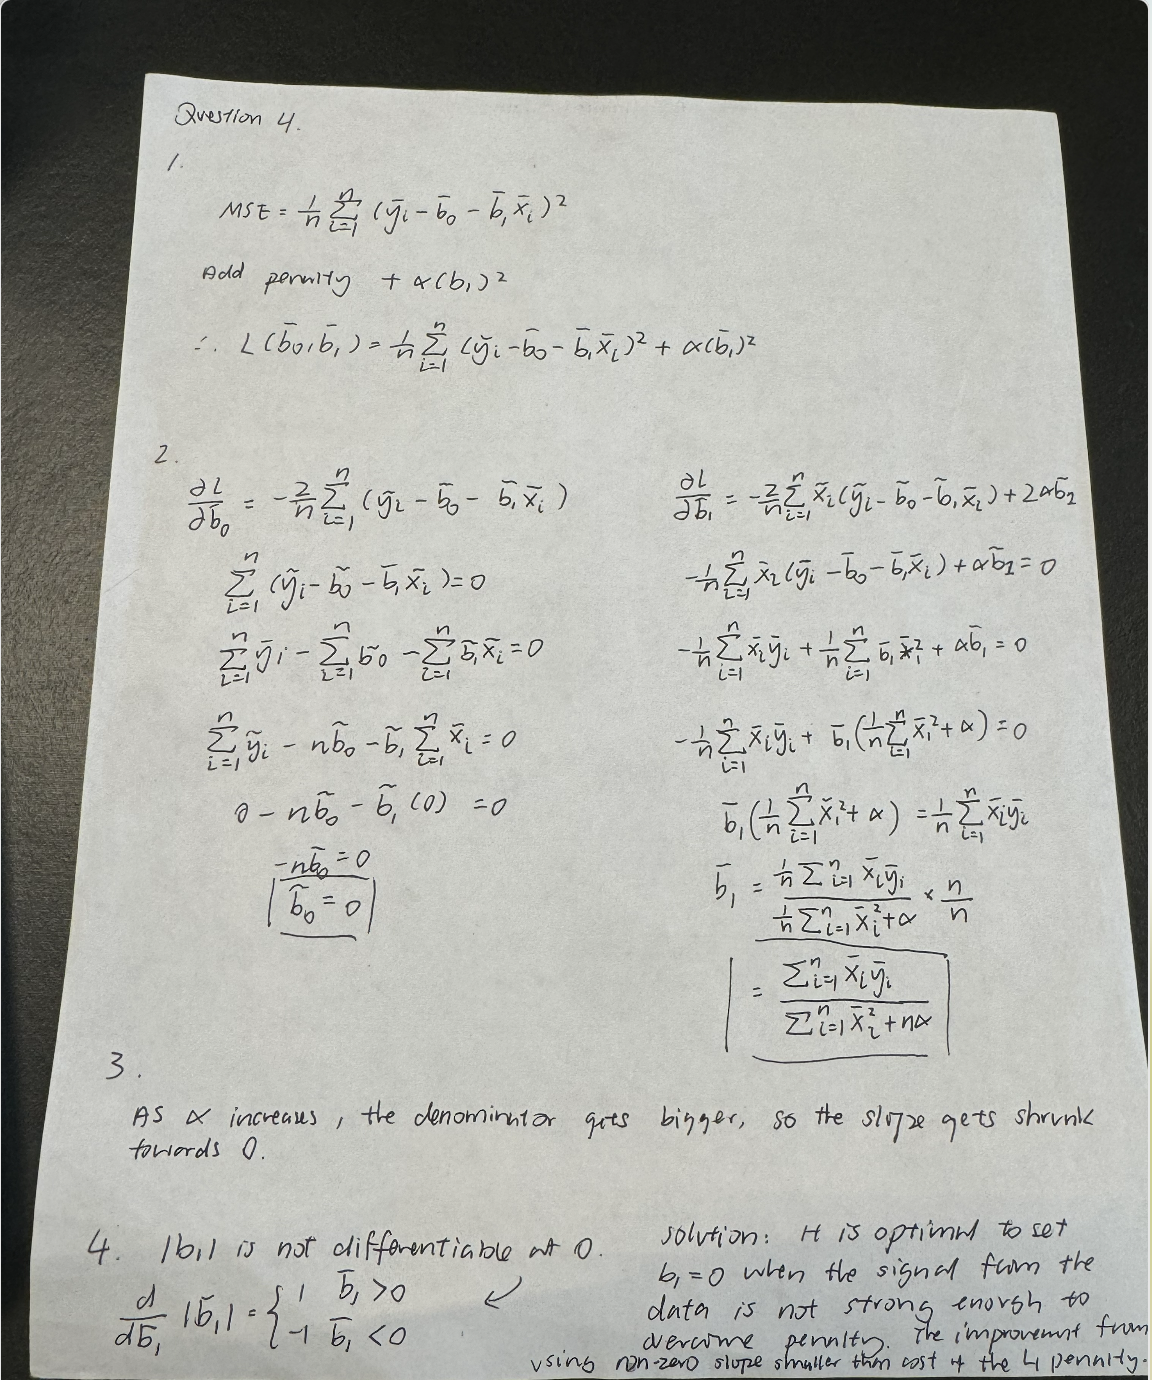

In [101]:
from IPython.display import Image, display
display(Image(filename="Question4.png"))